In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# %matplotlib inline

In [4]:
# read files
df_contacts = pd.read_csv("data/contacts-raw.csv")

df_companies = pd.read_csv("data/companies-raw.csv")

In [5]:
df_companies.columns = df_companies.columns.str.replace(' ','_').str.lower()
df_contacts.columns = df_contacts.columns.str.replace(' ','_').str.lower()

In [6]:
df_contacts.record_id.nunique()

5000

In [7]:
# df_contacts.info()
# df_contacts.head()

In [8]:
# check for duplicates
# df_contacts[ df_contacts.duplicated()].shape
# dedupe contacts
df_contacts = df_contacts.drop_duplicates()

In [9]:
df_contacts.info()
df_contacts.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   record_id                     5000 non-null   object
 1   email                         5000 non-null   object
 2   create_date                   5000 non-null   object
 3   custom_source                 5000 non-null   object
 4   self_reported_source          4073 non-null   object
 5   first_demo_booked_date        3407 non-null   object
 6   first_free_trial_signup_date  3997 non-null   object
dtypes: object(7)
memory usage: 312.5+ KB


,record_id,email,create_date,custom_source,self_reported_source,first_demo_booked_date,first_free_trial_signup_date
0,fd8556ad-71bd-4885-b99b-4ee0b804b20a,bradleyaaron@frost.info,2020-01-01 1:29:16,Physical Events - external,Youtube + Recherche,2023-04-10 20:29:09,2023-05-12 20:29:09
1,61731834-f813-4bec-92d9-33b4b2f2ef9a,roberthaley@mcguire.com,2020-01-01 2:26:26,Social organic - other,Online Suche,2020-11-17 4:50:05,NaN
2,01a03470-37c6-460f-a542-27d5ab0d98a5,arthurmcbride@fuentes.info,2020-01-01 5:36:02,Unidentifiable - Offline source,Suche nach passendem Software System und Nutzu...,2021-09-03 15:55:53,NaN
3,e5259b47-7924-42fe-855f-74f2cf120cca,johngibbs@duncan.com,2020-01-01 6:44:45,Podcast ads,Internet search,2020-06-05 21:32:17,2020-04-29 21:32:17
4,e845fe5b-7ad9-48bb-a857-b81337f5e273,todd40@garcia-olson.com,2020-01-01 21:04:32,Unidentifiable - Offline source,Beschprechen,2022-03-27 13:29:54,2022-01-31 13:29:54


In [10]:
# df_contacts.columns
contact_date_columns = ['first_demo_booked_date', 'first_free_trial_signup_date']

In [11]:
df_contacts[contact_date_columns] = df_contacts[contact_date_columns].apply(pd.to_datetime)

In [12]:
# df_contacts.custom_source.value_counts(dropna = False)
# df_contacts.record_id.duplicated().sum()

In [13]:
df_companies.info()
# df_companies.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   company_domain              3266 non-null   object
 1   record_id                   3266 non-null   object
 2   industry                    3266 non-null   object
 3   number_of_employees         3266 non-null   object
 4   region                      3266 non-null   object
 5   create_date                 3266 non-null   object
 6   became_a_lead_date          3266 non-null   object
 7   became_a_sql_date           1436 non-null   object
 8   became_an_opportunity_date  765 non-null    object
 9   became_a_customer_date      394 non-null    object
 10  churn_date                  95 non-null     object
dtypes: object(11)
memory usage: 280.8+ KB


In [14]:
co_date_cols = df_companies.columns[df_companies.columns.str.contains('became')]

In [15]:
co_date_cols = co_date_cols.append(pd.Index(["churn_date", "create_date"]))

In [16]:
df_companies[co_date_cols] = df_companies[co_date_cols].apply(pd.to_datetime)
# df_companies[co_date_cols]

In [17]:
# employee numbers -> ordered categorical 
df_companies.number_of_employees = pd.Categorical(df_companies.number_of_employees).reorder_categories(['1-10', '11-30', '31-50', '51-100', '100+'], ordered = True)

In [18]:
df_companies.create_date.equals(df_companies.became_a_lead_date)


True

In [19]:
df_companies.number_of_employees.value_counts(dropna = False).sort_index()
# df_companies.info()

number_of_employees
1-10      659
11-30     689
31-50     637
51-100    619
100+      662
Name: count, dtype: int64

In [20]:
# attempting join on record_id - failed, fair enough
pd.merge(df_companies, df_contacts, on = 'record_id', indicator = True)

,company_domain,record_id,industry,number_of_employees,region,create_date_x,became_a_lead_date,became_a_sql_date,became_an_opportunity_date,became_a_customer_date,churn_date,email,create_date_y,custom_source,self_reported_source,first_demo_booked_date,first_free_trial_signup_date,_merge


In [21]:
# df_companies.info()
df_companies.query('number_of_employees >= "51-100" and create_date >= "2020-01-01" and create_date < "2024-01-01"').describe()

,create_date,became_a_lead_date,became_a_sql_date,became_an_opportunity_date,became_a_customer_date,churn_date
count,1281,1281,582,297,157,45
mean,2021-10-19 06:02:17.242779136,2021-10-19 06:02:17.242779136,2021-12-02 02:15:41.463917824,2022-01-10 14:37:04.097643264,2022-02-15 07:12:17.700636928,2023-03-09 10:47:17.111110912
min,2020-01-01 02:26:26,2020-01-01 02:26:26,2020-01-12 13:32:33,2020-01-24 13:32:33,2020-04-07 19:19:14,2021-02-03 08:19:24
25%,2020-10-13 08:27:43,2020-10-13 08:27:43,2020-11-18 05:04:03,2021-01-01 23:19:37,2021-03-11 05:15:53,2022-04-21 15:56:14
50%,2021-08-23 11:00:21,2021-08-23 11:00:21,2021-09-18 08:57:56.500000,2021-11-04 10:29:41,2021-11-28 00:14:55,2023-03-21 18:11:26
75%,2022-10-30 05:33:42,2022-10-30 05:33:42,2022-12-14 11:53:35.750000128,2023-01-03 10:06:10,2023-02-14 07:55:47,2023-12-31 21:37:13
max,2023-12-29 18:53:17,2023-12-29 18:53:17,2024-03-15 18:31:09,2024-06-11 20:49:37,2024-09-05 20:49:37,2025-06-15 17:28:42


In [22]:
# attempting merge on doman - email domain
df_contacts[['email_name','email_domain' ]] = df_contacts.email.str.split("@", expand = True)

In [23]:
# attempting join on domain - all good
df_merged = pd.merge(
    df_companies, 
    df_contacts, 
    left_on = 'company_domain', 
    right_on ='email_domain', 
    indicator = True, 
    validate = "1:m"
)

In [24]:
df_merged._merge.value_counts()

_merge
both          5000
left_only        0
right_only       0
Name: count, dtype: int64

In [25]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   company_domain                5000 non-null   object        
 1   record_id_x                   5000 non-null   object        
 2   industry                      5000 non-null   object        
 3   number_of_employees           5000 non-null   category      
 4   region                        5000 non-null   object        
 5   create_date_x                 5000 non-null   datetime64[ns]
 6   became_a_lead_date            5000 non-null   datetime64[ns]
 7   became_a_sql_date             2272 non-null   datetime64[ns]
 8   became_an_opportunity_date    1260 non-null   datetime64[ns]
 9   became_a_customer_date        618 non-null    datetime64[ns]
 10  churn_date                    129 non-null    datetime64[ns]
 11  record_id_y                   

#### Operative 1. The client company tests a mixed approach offering a CTA for starting a free-trial and a CTA for booking a demo. Answer the following:

##### Is a prospect company more likely to convert from lead to customer if they first have a free-trial or if they first have a demo?

In [26]:
# # checks
# df_merged.company_domain.nunique() == df_merged.record_id_x.nunique()
# df_merged.groupby(['company_domain','record_id_x']).ngroups

In [27]:
company_first_event = (
df_merged.groupby(['company_domain', 'record_id_x'])
                    .agg({
                        'first_demo_booked_date': 'min',
                        'first_free_trial_signup_date': 'min',
                        'record_id_y': 'count',
                        'became_a_customer_date': lambda col: col.notna().any(),
                    })
)

In [28]:
# company_first_event.head()

In [29]:
company_first_event.became_a_customer_date.value_counts()
# describe(include='all')
# company_first_event.query('first_demo_booked_date.isnull() and first_free_trial_signup_date.isnull()')

became_a_customer_date
False    2872
True      394
Name: count, dtype: int64

In [30]:
company_first_event.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3266 entries, ('abbott.info', '5a8c8ff9-8f90-4455-8bf1-494f90c87ec9') to ('zuniga.org', '8925b1b5-eb3d-4db4-84eb-3a16b2e96d40')
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   first_demo_booked_date        2399 non-null   datetime64[ns]
 1   first_free_trial_signup_date  2702 non-null   datetime64[ns]
 2   record_id_y                   3266 non-null   int64         
 3   became_a_customer_date        3266 non-null   bool          
dtypes: bool(1), datetime64[ns](2), int64(1)
memory usage: 143.6+ KB


In [31]:
# impute NaT with future date for further porcessing
company_first_event[['first_free_trial_signup_date', 'first_demo_booked_date']] = company_first_event[['first_free_trial_signup_date', 'first_demo_booked_date']]\
            .fillna(pd.to_datetime('2030-01-01'))

In [32]:
company_first_event['co_first_event'] = \
(
    company_first_event.first_demo_booked_date > company_first_event.first_free_trial_signup_date 
).replace({ True: 'trial', False: 'demo' })

In [33]:
company_first_event.co_first_event.value_counts(dropna = False) #/ company_first_event.shape[0]

co_first_event
demo     1701
trial    1565
Name: count, dtype: int64

P(C|t) = Count of Companies( trial first AND Customer ) / Count of Companies (trial first)   
P(C|d) = Count of Companies( demo first AND Customer ) / Count of Companies (demo first)

In [34]:
company_first_event.query('co_first_event == "trial" & became_a_customer_date').shape[0] / company_first_event.query('co_first_event == "trial"').shape[0]

0.131629392971246

In [36]:
trial_conv(company_first_event)

0.131629392971246

In [67]:
company_first_event.query('co_first_event == "demo" & became_a_customer_date').shape[0] / company_first_event.query('co_first_event == "demo"').shape[0]

0.11052322163433274

In [68]:
demo_conv(company_first_event)

0.11052322163433274

###### Using seaborne plotting with confidence interval boorstrapping

In [53]:
# company_first_event.columns
# company_first_event.shape
# company_first_event.isnull().sum()
# company_first_event.info()
# company_first_event.query('became_a_customer_date')

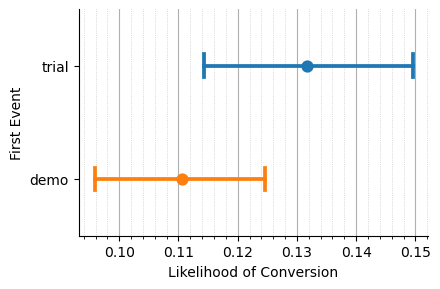

In [78]:
# plot winrates with .95 confidence intervals
# sns.set_style("whitegrid")

g = sns.catplot(
    data= company_first_event, 
    y='co_first_event',
    hue = 'co_first_event',
    x='became_a_customer_date', 
    kind='point',
    errorbar=('ci', 95), # Configures the 95% confidence interval
    capsize=.2,
    linestyle='none',
    height = 3, 
    aspect = 1.5, 
)

# Customizing labels
g.set_axis_labels("Likelihood of Conversion", "First Event")
# plt.title("Conditional Likelihood of Becoming a Customer")
# plt.show()

minor_step = 0.002
for ax in g.axes.flat:
    # Set the locator for the x-axis
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_step))
    # Customize the appearance of the minor grid
    ax.grid(which='minor', axis='x', linestyle=':', linewidth='0.5', color='gray', alpha=0.5)
    ax.grid(which='major', axis='x', linestyle='-', linewidth='0.8')

chi-squared test

In [79]:
from scipy.stats import chi2_contingency

# 1. Create a contingency table (cross-tabulation)
# This counts how many trials/demos became customers vs. did not
contingency_table = pd.crosstab(
    company_first_event['co_first_event'], 
    company_first_event['became_a_customer_date']
)

print("Contingency Table:")
print(contingency_table)
print("-" * 30)

# 2. Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

Contingency Table:
became_a_customer_date  False  True 
co_first_event                      
demo                     1513    188
trial                    1359    206
------------------------------
Chi-squared Statistic: 3.2267
P-value: 0.0724
Degrees of Freedom: 1


Check it with Bayes : P(C|t) = P(t|C) * P(C) / P(t)   
P(C|d) = P(d|C) * P(C) / P(d)

In [56]:
customer_first_event = company_first_event.query('became_a_customer_date')

In [57]:
# P(C)
P_Customer = customer_first_event.shape[0] / company_first_event.shape[0]

In [58]:
# P(d)
P_demo = company_first_event.query('co_first_event == "demo"').shape[0] / company_first_event.shape[0]

In [59]:
# P(t)
P_trial = company_first_event.query('co_first_event == "trial"').shape[0] / company_first_event.shape[0]

In [60]:
tmp_s = customer_first_event.co_first_event.value_counts() / customer_first_event.shape[0]

In [80]:
tmp_s.demo * P_Customer / P_demo

np.float64(0.11052322163433274)

In [81]:
tmp_s.trial * P_Customer / P_trial

np.float64(0.131629392971246)

#### Operative 2. The client company tries to evaluate recent weekly cohorts of Lead companies and their conversion to sales qualified companies. As a reference you analyze companies with 50 or more employees that were created in 2020-2023. Answer the following:

In [63]:
# df_merged.info()

In [64]:
# companies are enough
df_co_cohort = (
df_companies
    .query('number_of_employees >= "51-100" and create_date >= "2020-01-01" and create_date < "2024-01-01"')
    .copy()
    .reset_index()
)

##### Given cohort week X, after how many weeks (X+n) should week X be fully evaluated, assuming the week should be evaluated after the time in which 90% of all leads that convert to SQL should have been converted?

In [65]:
df_co_cohort.describe()

,index,create_date,became_a_lead_date,became_a_sql_date,became_an_opportunity_date,became_a_customer_date,churn_date
count,1281.000000,1281,1281,582,297,157,45
mean,1626.117096,2021-10-19 06:02:17.242779136,2021-10-19 06:02:17.242779136,2021-12-02 02:15:41.463917824,2022-01-10 14:37:04.097643264,2022-02-15 07:12:17.700636928,2023-03-09 10:47:17.111110912
min,1.000000,2020-01-01 02:26:26,2020-01-01 02:26:26,2020-01-12 13:32:33,2020-01-24 13:32:33,2020-04-07 19:19:14,2021-02-03 08:19:24
25%,814.000000,2020-10-13 08:27:43,2020-10-13 08:27:43,2020-11-18 05:04:03,2021-01-01 23:19:37,2021-03-11 05:15:53,2022-04-21 15:56:14
50%,1644.000000,2021-08-23 11:00:21,2021-08-23 11:00:21,2021-09-18 08:57:56.500000,2021-11-04 10:29:41,2021-11-28 00:14:55,2023-03-21 18:11:26
75%,2434.000000,2022-10-30 05:33:42,2022-10-30 05:33:42,2022-12-14 11:53:35.750000128,2023-01-03 10:06:10,2023-02-14 07:55:47,2023-12-31 21:37:13
max,3264.000000,2023-12-29 18:53:17,2023-12-29 18:53:17,2024-03-15 18:31:09,2024-06-11 20:49:37,2024-09-05 20:49:37,2025-06-15 17:28:42
std,944.051523,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
df_co_cohort = df_co_cohort.set_index("create_date")

In [67]:
df_co_cohort['weeks_to_SQL'] = \
(df_co_cohort.became_a_sql_date - df_co_cohort.became_a_lead_date)/np.timedelta64(1, 'W')


In [68]:
# df_co_cohort index.to_series().dt.isocalendar().week # df_co_cohort query('not weeks_to_SQL.isnull()')

In [69]:
def q90(x):
    return x.quantile(0.9)

tmp_df = df_co_cohort.resample("W").agg({'weeks_to_SQL':[list,q90], 'index' : 'count', 'became_a_sql_date': 'count'}).sort_index()

In [70]:
tmp_df.shape
tmp_df.head()
# tmp_df[("weeks_to_SQL", "q90")].quantile(.9)

weeks_to_SQL             \
                                                          list        q90   
create_date                                                                 
2020-01-05   [nan, 3.857142857142857, 6.0, 11.7142857142857...  11.142857   
2020-01-12   [nan, 13.142857142857142, nan, 4.1428571428571...  13.214286   
2020-01-19   [13.285714285714286, 10.714285714285714, 5.142...  12.771429   
2020-01-26   [nan, 2.7142857142857144, 3.7142857142857144, ...   4.914286   
2020-02-02   [nan, nan, 6.857142857142857, 4.14285714285714...   9.542857   

            index became_a_sql_date  
            count             count  
create_date                          
2020-01-05     10                 6  
2020-01-12     12                 6  
2020-01-19      5                 3  
2020-01-26      9                 4  
2020-02-02     11                 5

In [71]:
df_co_cohort.weeks_to_SQL.quantile(.9)

np.float64(12.142857142857142)

In [85]:
df_co_cohort.query('~became_a_sql_date.isnull()').weeks_to_SQL.quantile(.9)

np.float64(12.142857142857142)